# 2026 Survey on Open Source in Energy and Subsurface

## Read the data and clean up

In [46]:
import pandas as pd

standard_nas_without_none = [
    '', '<NA>', 'N/A', 'NA', 'NULL', 'NaN', '-NaN', 'n/a', 'nan', '-nan', 'null'
]

df = (pd.read_csv("./Responses.csv",
                  keep_default_na=False, na_values=standard_nas_without_none)
        .drop(columns=["Timestamp"])
     )
df.shape

(89, 45)

In [47]:
new_names = {
    "In which region are you located?": 'region',
    "What is your primary, current technical domain?": 'domain',
    "During the last 6 months, how much of your work time have you spent writing or reviewing code or documentation?": 'time_prop',
    "Which sector best describes your organization?": 'org_sector',
    "What size is your organization?": 'org_size',
    "When evaluating technical tools for use in a project, how heavily do you and/or your team weigh whether a software option was open-source vs. proprietary?": 'open_v_prop',
    "In the past 6 months, how often have you used open-source software for subsurface or other technical processing, modeling, or analysis?": 'open_often',
    "Thinking about the open-source subsurface toolset you used in the past 6 months, what were the main reasons for choosing it over a proprietary alternative?": 'open_why',
    "In the past 6 months, have you encountered a workflow-breaking bug or security vulnerability in a subsurface open-source tool that delayed your project?": 'open_bug',
    "Are you a core contributor to any open source repositories? (In any domain, not only subsurface.)\n\nA 'core contributor' is someone with administrative or write access to the repository. This includes the role of 'maintainer'.": 'core',
    "Of the repositories to which you are a core contributor, are any of the projects related to subsurface?": 'subsurface',
    "Thinking about the primary subsurface open source project you contribute to, how many other core contributors are there on that project?": 'core_num',
    "Again thinking about this project, how was your time accounted for?": 'core_time',
    "Again thinking about this project, what was the primary funding mechanism keeping the subsurface open-source tools you maintain or help maintain afloat?": 'core_recent_funding',
    "Looking ahead to the next 6 to 12 months as a core contributor or maintainer, how do you feel about the following aspects: [Shipping features]": 'core_ship',
    "Looking ahead to the next 6 to 12 months as a core contributor or maintainer, how do you feel about the following aspects: [Fixing bugs]": 'core_fix',
    "Looking ahead to the next 6 to 12 months as a core contributor or maintainer, how do you feel about the following aspects: [Reviewing contributions]": 'core_review',
    "Looking ahead to the next 6 to 12 months as a core contributor or maintainer, how do you feel about the following aspects: [Getting recognition]": 'core_recog',
    "Looking ahead to the next 6 to 12 months as a core contributor or maintainer, how do you feel about the following aspects: [Contributors' use of AI]": 'core_ai_contribs',
    "Looking ahead to the next 6 to 12 months as a core contributor or maintainer, how do you feel about the following aspects: [Your project's use of AI]": 'core_ai',
    "Looking ahead to the next 6 to 12 months as a core contributor or maintainer, how do you feel about the following aspects: [Upstream supply chain attacks]": 'core_supply_chain',
    "Looking ahead to the next 6 to 12 months as a core contributor or maintainer, how do you feel about the following aspects: [Your project(s) being attacked]": 'core_attack',
    "Looking ahead to the next 6 to 12 months as a core contributor or maintainer, how do you feel about the following aspects: [Project administration]": 'core_admin',
    "Looking ahead to the next 6 to 12 months as a core contributor or maintainer, how do you feel about the following aspects: [Community management]": 'core_community',
    "Looking ahead to the next 6 to 12 months as a core contributor or maintainer, how do you feel about the following aspects: [Funding the work]": 'core_funding',
    "Looking ahead to the next 6 to 12 months as a core contributor or maintainer, how do you feel about the following aspects: [Strategic planning]": 'core_planning',
    "In the past 6 months, how many pull requests (PRs), code commits, or documentation fixes have you submitted to open-source repositories to which you are not a core contributor?": 'contrib_prs',
    "In the past 6 months, what have been the barriers to contributing code or documentation back to the subsurface tools you use?": 'contrib_barriers',
    "Thinking about your contributions in the last 6 months, what proportion of them were submitted to subsurface open-source repositories?": 'contrib_subsurface',
    "In the past 6 months, what kind of contribution(s) have you made? Check all that apply.": 'contrib_kinds',
    "How often do you use AI assistants or agentic tools in your work? For example, for help with research, brainstorming, translation, or coding.": 'ai_freq',
    "To what extent do you trust the assistance of AI assistants and agentic tools?": 'ai_trust',
    "In the past 6 months, have you used AI code assistants (e.g., Copilot, ChatGPT, Claude) to write, debug, or document code meant for subsurface open-source applications?": 'ai_subsurface',
    "How concerned are you about the security, copyright, or intellectual property (IP) risks of AI-assisted code being merged into open-source repositories your organization depends on?": 'ip_depend',
    "How concerned are you about the security, copyright, or intellectual property (IP) risks of AI-assisted code being merged into open-source repositories your organization produces?": 'ip_merge',
    'To what extent do you agree with this statement: "AI code assistants are lowering the barrier for non-programmers to make use of subsurface open source projects."': 'barrier_use',
    'To what extent do you agree with this statement: "AI code assistants are lowering the barrier for non-programmers to contribute to subsurface open source projects."': 'barrier_contrib',
    "In the past 6 months, how would you characterize your organizational leadership’s general attitude toward adopting open-source software?": 'leaders',
    "Which of the following actions has your organization taken? Select all that apply.": 'org_actions',
    "In the last 6 months, and to the best of your knowledge, have any of your projects been affected by an upstream dependency doing any of the following: [Changing its license]": 'dep_license',
    "In the last 6 months, and to the best of your knowledge, have any of your projects been affected by an upstream dependency doing any of the following: [Being forked]": 'dep_fork',
    "In the last 6 months, and to the best of your knowledge, have any of your projects been affected by an upstream dependency doing any of the following: [Being deprecated]": 'dep_deprecated',
    "In the last 6 months, and to the best of your knowledge, have any of your projects been affected by an upstream dependency doing any of the following: [Being attacked or infected]": 'dep_attack',
    "Based on your observations in the past 6 months, how sustainable do you consider the maintenance health of the subsurface open-source ecosystem?": 'sustainable',
    "That's the end of the survey. Is there anything you'd like to share?": 'other'
}
df = df.rename(columns=new_names)

In [48]:
# Two people chose 50-50 geo/ML. I am moving one into geo and the other into ML.
df.loc[df['domain'] == "geoscience and data science", 'domain'] = 'Software engineering, computer science, data science'
df.loc[df['domain'] == "I would say intersection of ML and geophysics as of 2 years ago", 'domain'] = 'Applied sciences, eg economic geology, geophysics'

# Fix a typo.
df.loc[df['open_v_prop'] == "Strongly preferr open-source options", 'open_v_prop'] = 'Strongly prefer open-source options'

# Split lists, but comma-capital only, oof.
pattern = r',\s+(?=[A-Z])'
df['open_why'] = df['open_why'].str.split(pattern)
df['contrib_barriers'] = df['contrib_barriers'].str.split(pattern) 
df['contrib_kinds'] = df['contrib_kinds'].str.split(pattern)
df['org_actions'] = df['org_actions'].str.split(pattern)

## Set some dtypes

Helps with ordering in tables and plots.

In [49]:
unordered = {
    'domain': ['Software engineering, computer science, data science', 'Applied sciences, eg economic geology, geophysics',
               'Well / field / site related (operations, drilling)', 'Reservoir engineering, geomodeling'],
    'org_sector': ['Operating company', 'Academia or research institute', 'Service or technology company',
                   'Independent consultant or freelance', 'Energy company ', 'Government or regulatory body'],
}

for column, responses in unordered.items():
    df[column] = df[column].astype(pd.CategoricalDtype(categories=responses, ordered=False))

ordered = {
    'region': ['North America', 'South America', 'Europe', 'Africa / Middle East', 'Asia', 'Australasia'],
    'time_prop': ['More than 50%', 'Between 20% and 50%', 'Less than 20% (one day per week)', "I don't write or review code or documentation"],
    'org_size': ['1 to 9 employees', '10 to 99 employees', '100 to 999 employees', '1000 to 9999 employees', '10 000 or more employees'],
    'open_v_prop': ['Strongly prefer open-source options', 'Lean toward open-source options',
                    'Neutral / No weight', 'Lean toward proprietary options', 'Strongly prefer proprietary options'],
    'open_often': ['Daily',
                   'Weekly',
                   'Monthly',
                   'Rarely',
                   "Never, or I don't perform this kind of work",
                   "I don't know if I use open-source software or not"],
    'open_bug': ['No', 'Yes, once', 'Yes, multiple times', 'Unsure'],  # Also has NaNs
    'core': ['No', 'Yes, one', 'Yes, more than one'],
    'subsurface': ['No', 'Yes, one', 'Yes, more than one', 'Yes, all of them'],  # Also has NaNs
    'core_num': ['There are no other core contributors', 'One other', '2 to 5 others', 'More than 5 others'],  # Also has NaNs
    'core_time': list(reversed(['Not applicable (I did not make contributions in the past 6 months)',
                                'Entirely unsupported (done on my own personal/volunteer time)',
                                'Partially supported (done occasionally/informally during working hours)',
                                'Fully supported and done during my paid organizational working hours'])), # Also has NaNs
    'core_recent_funding': ['A single industry source, eg private company',
                            'Joint Industry Projects (JIPs) / Corporate consortiums',
                            'Dedicated foundational funding (e.g., NumFOCUS, Linux Foundation)',
                            'Public academic grants or government-funded research initiatives',
                            'Purely unfunded, volunteer in-kind developer time',
                            'Unknown or unsure'], # Also has NaNs
    'contrib_prs': ["None", '1 or 2', '3 to 5', '6 to 10', 'More than 10'], # Also has NaNs
    'contrib_subsurface': ['None of them', 'A few of them', 'Most of them', 'All of them'],
    'ai_freq': ['Never', 'Rarely', 'Weekly', 'Daily', 'Continuously'],  # Also has NaNs
    'ai_subsurface': ["No, I don't code",
                      "No, I code but I don't use AI for programming tasks",
                      'Yes, occasionally',
                      'Yes, frequently'],
    'leaders': ['Actively hostile (Explicitly banned or heavily discouraged)',
                'Skeptical / Risk-averse (Preferred proprietary alternatives due to liability concerns)',
                'Indifferent or unaware', 'Curious',
                'Supportive but passive (Permitted, but not actively strategized)',
                'Enthusiastic (Viewed as a core competitive advantage)'],
    'sustainable': ['Critical state (Several tools we use appear abandoned)',
                    'Fragile / At risk of severe maintainer burnout or code rot',
                    'Moderately sustainable (Stable but reliant on a few key individuals/companies)',
                    'Highly sustainable (Well-funded, robust contributor pipelines)'],
}

for column, responses in ordered.items():
    df[column] = df[column].astype(pd.CategoricalDtype(categories=responses, ordered=True))

all_the_cores = ['Excited or safe', 'Hopeful', 'So-so', 'Nervous', 'Anxious or exposed']
for column in ['core_ship', 'core_fix', 'core_review', 'core_recog',
       'core_ai_contribs', 'core_ai', 'core_supply_chain', 'core_attack',
       'core_admin', 'core_community', 'core_funding', 'core_planning']:
    df[column] = df[column].astype(pd.CategoricalDtype(categories=all_the_cores, ordered=True))

all_the_deps = ['No', 'Yes, with no effect on us', 'Yes, with negative effects on us', 'Yes, with positive effects on us']
for column in ['dep_license', 'dep_fork', 'dep_deprecated', 'dep_attack']:
    df[column] = df[column].astype(pd.CategoricalDtype(categories=all_the_deps, ordered=True))

/var/folders/p0/4kcb_5yn4s30yqhjghdzmnh40000gp/T/ipykernel_52661/4080032416.py:9: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df[column] = df[column].astype(pd.CategoricalDtype(categories=responses, ordered=False))


In [50]:
# Rename some categories to make them easier to read.
df["core_time"] = df["core_time"].cat.rename_categories(["Not applicable", "Unsupported", "Partially supported", "Fully supported"])
df["core_recent_funding"] = df["core_recent_funding"].cat.rename_categories(["Single source", "Consortium", "Foundation", "Public", "Unfunded", "Unsure"])
df["leaders"] = df["leaders"].cat.rename_categories(["Hostile", "Skeptical", "Indifferent", "Curious", "Supportive", "Enthusiastic"])
df["sustainable"] = df["sustainable"].cat.rename_categories(["Critical", "Fragile", "Stable", "Robust"])

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

## About the survey

The survey ran from noon on 18 May 2026 to noon on 7 June 2026.

In [52]:
len(df)

89

---

## About you and your organization

<div class="alert alert-block alert-info" style="padding-bottom:24px;">
  <ul>
    <li>In which region are you located? <code>df['region']</code></li>
    <li>What is your primary, current technical domain? <code>df['domain']</code></li>
    <li>During the last 6 months, how much of your work time have you spent writing or reviewing code or documentation? <code>df['time_prop']</code></li>
    <li>Which sector best describes your organization? <code>df['org_sector']</code></li>
    <li>What size is your organization? <code>df['org_size']</code></li>
  </ul>
</div>

In [53]:
q = "In which region are you located?"

counts = (df['region']
      .value_counts(sort=False)
      .reset_index()
)
(counts.style
       .set_properties(**{'width': '160px'})
       .hide(axis='index')
       .set_caption(q)
)

region,count
North America,29
South America,1
Europe,38
Africa / Middle East,1
Asia,9
Australasia,11


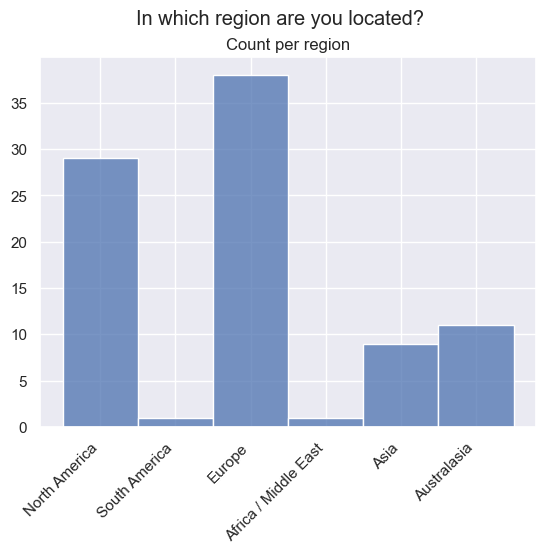

In [54]:
ax = sns.histplot(df, x='region')
ax.set_xticks(ax.get_xticks()) # Fix ticks to avoid the warning.
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel(None)
ax.set_ylabel(None)
plt.suptitle("In which region are you located?")
ax.set_title("Count per region")
plt.show()

In [55]:
q = "What is your primary, current technical domain?"

counts = (df['domain']
      .value_counts(sort=True)
      .reset_index()
)
(counts.style
       .set_properties(subset='domain', **{'width': '200px'})
       .hide(axis='index')
       .set_caption(q)
)

domain,count
"Applied sciences, eg economic geology, geophysics",58
"Software engineering, computer science, data science",22
"Well / field / site related (operations, drilling)",5
"Reservoir engineering, geomodeling",3


In [56]:
crosstab = pd.crosstab(index=df['org_sector'], 
                        columns=df['domain'],
                        margins=True,
                        margins_name='Total'
                       ).reset_index()

(crosstab.style
         .hide(axis='index')
         .set_caption("Domain by Sector")
         .set_table_styles([{
             'selector': 'caption',
             'props': [('font-weight', 'bold'), ('font-size', '14px')]
         }])
)

org_sector,"Software engineering, computer science, data science","Applied sciences, eg economic geology, geophysics","Well / field / site related (operations, drilling)","Reservoir engineering, geomodeling",Total
Operating company,8,16,1,0,25
Academia or research institute,0,17,0,1,18
Service or technology company,11,13,3,1,28
Independent consultant or freelance,1,9,1,0,11
Energy company,0,0,0,1,1
Government or regulatory body,2,3,0,0,5
Total,22,58,5,3,88


In [12]:
q = "During the last 6 months, how much of your work time have you spent writing or reviewing code or documentation?"

counts = (df['time_prop']
      .value_counts(sort=False)
      .reset_index()
)
(counts.style
       .set_properties(subset='time_prop', **{'width': '200px'})
       .hide(axis='index')
       .set_caption(q)
)

time_prop,count
More than 50%,31
Between 20% and 50%,21
Less than 20% (one day per week),29
I don't write or review code or documentation,8


In [13]:
q = "Which sector best describes your organization?"

counts = (df['org_sector']
      .value_counts(sort=True)
      .reset_index()
)
(counts.style
       .set_properties(subset='org_sector', **{'width': '200px'})
       .hide(axis='index')
       .set_caption(q)
)

org_sector,count
Service or technology company,28
Operating company,25
Academia or research institute,19
Independent consultant or freelance,11
Government or regulatory body,5
Energy company,1


In [14]:
crosstab = pd.crosstab(index=df['org_sector'], 
                        columns=df['org_size'],
                        margins=True,
                        margins_name='Total'
                       ).reset_index()

(crosstab.style
         .hide(axis='index')
         .set_caption("Organization Size by Sector")
         .set_table_styles([{
             'selector': 'caption',
             'props': [('font-weight', 'bold'), ('font-size', '14px')]
         }])
)

org_sector,1 to 9 employees,10 to 99 employees,100 to 999 employees,1000 to 9999 employees,10 000 or more employees,Total
Operating company,1,2,3,6,13,25
Academia or research institute,0,2,2,8,7,19
Service or technology company,7,8,6,1,6,28
Independent consultant or freelance,9,1,1,0,0,11
Energy company,0,0,0,0,1,1
Government or regulatory body,0,1,2,1,1,5
Total,17,14,14,16,28,89


---

## Your use of open source software

<div class="alert alert-block alert-info" style="padding-bottom:24px;">
  <ul>
    <li>When evaluating technical tools for use in a project, how heavily do you and/or your team weigh whether a software option was open-source vs. proprietary? <code>df['open_v_prop']</code></li>
    <li>In the past 6 months, how often have you used open-source software for subsurface or other technical processing, modeling, or analysis? <code>df['open_often']</code></li>
    <li>Thinking about the open-source subsurface toolset you used in the past 6 months, what were the main reasons for choosing it over a proprietary alternative? <code>df['open_why']</code></li>
    <li>In the past 6 months, have you encountered a workflow-breaking bug or security vulnerability in a subsurface open-source tool that delayed your project? <code>df['open_bug']</code></li>
  </ul>
</div>

In [15]:
q = "When evaluating technical tools for use in a project, how heavily do you and/or your team weigh whether a software option was open-source vs. proprietary??"

counts = (df['open_v_prop']
      .value_counts(sort=False)
      .reset_index()
)
(counts.style
       .hide(axis='index')
       .set_caption(q)
)

open_v_prop,count
Strongly prefer open-source options,34
Lean toward open-source options,23
Neutral / No weight,14
Lean toward proprietary options,11
Strongly prefer proprietary options,7


In [16]:
q = "In the past 6 months, how often have you used open-source software for subsurface or other technical processing, modeling, or analysis?"

counts = (df['open_often']
      .value_counts(sort=False)
      .reset_index()
)
(counts.style
       .hide(axis='index')
       .set_caption(q)
)

open_often,count
Daily,44
Weekly,17
Monthly,7
Rarely,19
"Never, or I don't perform this kind of work",2
I don't know if I use open-source software or not,0


In [17]:
q = "Thinking about the open-source subsurface toolset you used in the past 6 months, what were the main reasons for choosing it over a proprietary alternative?"

counts = (df['open_why']
    .explode()
    .value_counts()
    .reset_index(name='count')
)
(counts.loc[counts['count'] > 1]
       .style
       .hide(axis='index')
       .set_caption(q)
)
# NB Respondents could choose multiple reasons.

open_why,count
Transparency and mathematical auditability of the underlying physics/algorithms,54
Cost / No licensing fees,53
Extensibility (ability to write custom plugins/scripts),53
Better interoperability and alignment with open data standards,24
There are no proprietary alternatives,14


In [18]:
q = "In the past 6 months, have you encountered a workflow-breaking bug or security vulnerability in a subsurface open-source tool that delayed your project?"

counts = (df['open_bug']
      .value_counts(sort=False)
      .reset_index()
)
(counts.style
       .set_properties(subset='open_bug', **{'width': '200px'})
       .hide(axis='index')
       .set_caption(q)
)

open_bug,count
No,58
"Yes, once",3
"Yes, multiple times",14
Unsure,12


---

## Your activities as a core contributor or maintainer

<div class="alert alert-block alert-info" style="padding-bottom:24px;">
  <ul>
    <li>Are you a core contributor to any open source repositories? (In any domain, not only subsurface.) A 'core contributor' is someone with administrative or write access to the repository. This includes the role of 'maintainer'. <code>df['core']</code></li>
    <li>Of the repositories to which you are a core contributor, are any of the projects related to subsurface? <code>df['subsurface']</code></li>
    <li>Thinking about the primary subsurface open source project you contribute to, how many other core contributors are there on that project? <code>df['core_num']</code></li>
    <li>Again thinking about this project, how was your time accounted for? <code>df['core_time']</code></li>
    <li>Again thinking about this project, what was the primary funding mechanism keeping the subsurface open-source tools you maintain or help maintain afloat? <code>df['core_recent_funding']</code></li>
    <li>Looking ahead to the next 6 to 12 months as a core contributor or maintainer, how do you feel about the following aspects:
      <ul>
        <li>Shipping features <code>df['core_ship']</code></li>
        <li>Fixing bugs <code>df['core_fix']</code></li>
        <li>Reviewing contributions <code>df['core_review']</code></li>
        <li>Getting recognition <code>df['core_recog']</code></li>
        <li>Contributors' use of AI <code>df['core_ai_contribs']</code></li>
        <li>Your project's use of AI <code>df['core_ai']</code></li>
        <li>Upstream supply chain attacks <code>df['core_supply_chain']</code></li>
        <li>Your project(s) being attacked <code>df['core_attack']</code></li>
        <li>Project administration <code>df['core_admin']</code></li>
        <li>Community management <code>df['core_community']</code></li>
        <li>Funding the work <code>df['core_funding']</code></li>
        <li>Strategic planning <code>df['core_planning']</code></li>
      </ul></li>
  </ul>
</div>


In [19]:
q = "Are you a core contributor to any open source repositories?"

counts = (df['core']
      .value_counts(sort=False)
      .reset_index()
)
(counts.style
       .set_properties(**{'width': '160px'})
       .hide(axis='index')
       .set_caption(q)
)

core,count
No,61
"Yes, one",10
"Yes, more than one",18


These **28 respondents** are the only ones included in the following data.

In [20]:
q = "Of the repositories to which you are a core contributor, are any of the projects related to subsurface?"


counts = (df['subsurface']
      .value_counts(sort=False)
      .reset_index()
)
(counts.style
       .set_properties(**{'width': '160px'})
       .hide(axis='index')
       .set_caption(q)
)

subsurface,count
No,5
"Yes, one",9
"Yes, more than one",9
"Yes, all of them",5


In [21]:
q = "Thinking about the primary subsurface open source project you contribute to, how many other core contributors are there on that project?"

counts = (df['core_num']
      .value_counts(sort=False)
      .reset_index()
)
(counts.style
       .set_properties(**{'width': '160px'})
       .hide(axis='index')
       .set_caption(q)
)

core_num,count
There are no other core contributors,12
One other,4
2 to 5 others,8
More than 5 others,4


Note that "One other" means two total, etc.

In [22]:
q = "Again thinking about this project, how was your time accounted for?"

counts = (df['core_time']
      .value_counts(sort=False)
      .reset_index()
)
(counts.style
       .set_properties(**{'width': '160px'})
       .hide(axis='index')
       .set_caption(q)
)

core_time,count
Not applicable,8
Unsupported,11
Partially supported,8
Fully supported,1


In [23]:
q = "Again thinking about this project, what was the primary funding mechanism keeping the subsurface open-source tools you maintain or help maintain afloat?"

counts = (df['core_recent_funding']
      .value_counts(sort=False)
      .reset_index()
)
(counts.style
       .set_properties(**{'width': '160px'})
       .hide(axis='index')
       .set_caption(q)
)

core_recent_funding,count
Single source,5
Consortium,2
Foundation,1
Public,10
Unfunded,9
Unsure,1


In [24]:
print(f"So {100*9/28:.1f}% of respondents are working on unfunded projects.")

So 32.1% of respondents are working on unfunded projects.


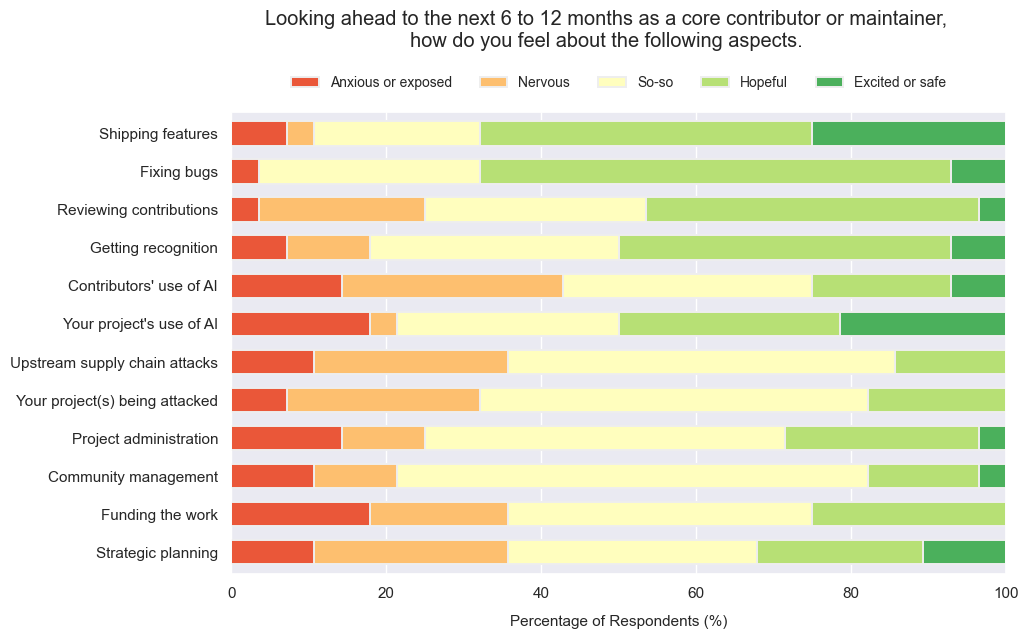

In [25]:
q = "Looking ahead to the next 6 to 12 months as a core contributor or maintainer,\nhow do you feel about the following aspects."
columns_dict = {
    'core_ship': 'Shipping features',
    'core_fix': 'Fixing bugs',
    'core_review': 'Reviewing contributions',
    'core_recog': 'Getting recognition',
    'core_ai_contribs': "Contributors' use of AI",
    'core_ai': "Your project's use of AI",
    'core_supply_chain': 'Upstream supply chain attacks',
    'core_attack': 'Your project(s) being attacked',
    'core_admin': 'Project administration',
    'core_community': 'Community management',
    'core_funding': 'Funding the work',
    'core_planning': 'Strategic planning'
}

cats = df['core_ship'].dtype.categories
plot_data = {}
for col, label in columns_dict.items():
    counts = df[col].value_counts(normalize=True).reindex(cats).fillna(0) * 100
    plot_data[label] = counts
plot_df = pd.DataFrame(plot_data).T

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("RdYlGn_r", 5)
plot_df.plot(kind='barh', stacked=True, ax=ax, color=colors, edgecolor='#eeeeee', lw=1.4, width=0.65)
ax.set_xlabel('Percentage of Respondents (%)', fontsize=11, labelpad=10)
ax.set_xlim(0, 100)
ax.invert_yaxis()
ax.invert_xaxis()
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(reversed(range(0, 101, 20)))
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=5, fontsize=10, frameon=False)
plt.suptitle(q, y=1.05)
plt.show()

---

## Your activities as a non-core contributor

<div class="alert alert-block alert-info" style="padding-bottom:24px;">
  <ul>
    <li>In the past 6 months, how many pull requests (PRs), code commits, or documentation fixes have you submitted to open-source repositories to which you are not a core contributor? <code>df['contrib_prs']</code></li>
    <li>In the past 6 months, what have been the barriers to contributing code or documentation back to the subsurface tools you use? <code>df['contrib_barriers']</code></li>
    <li>Thinking about your contributions in the last 6 months, what proportion of them were submitted to subsurface open-source repositories? <code>df['contrib_subsurface']</code></li>
    <li>In the past 6 months, what kind of contribution(s) have you made? Check all that apply. <code>df['contrib_kinds']</code></li>
  </ul>
</div>

In [26]:
q = "In the past 6 months, how many pull requests (PRs), code commits, or documentation fixes have you submitted to open-source repositories to which you are not a core contributor?"
    
counts = (df['contrib_prs']
      .value_counts(sort=False)
      .reset_index()
)
(counts.style
       .set_properties(**{'width': '160px'})
       .hide(axis='index')
       .set_caption(q)
)

contrib_prs,count
None,56
1 or 2,16
3 to 5,11
6 to 10,0
More than 10,6


In [27]:
q = "In the past 6 months, what have been the barriers to contributing code or documentation back to the subsurface tools you use?"

counts = (df['contrib_barriers']
    .explode()
    .value_counts(sort=True)
    .reset_index(name='count')
)
(counts.loc[counts['count'] > 1]
       .style
       .hide(axis='index')
       .set_caption(q)
)
# NB Respondents could choose multiple barriers.

contrib_barriers,count
"Lack of institutional time, permission, or career incentives",43
"No barriers, or the need did not arise",38
"I did not know, or was not sure, that I could contribute",15
"Overly complex contribution pipelines (e.g., confusing CLA sign-offs, rigid CI/CD testing)",12
Lack of clear developer documentation or onboarding guidance,11
Unresponsive or unwelcoming project maintainers,4


In [28]:
q = "Thinking about your contributions in the last 6 months, what proportion of them were submitted to subsurface open-source repositories?"

counts = (df['contrib_subsurface']
      .value_counts(sort=False)
      .reset_index()
)
(counts.style
       .set_properties(**{'width': '160px'})
       .hide(axis='index')
       .set_caption(q)
)

contrib_subsurface,count
None of them,12
A few of them,5
Most of them,4
All of them,12


In [29]:
q = "In the past 6 months, what kind of contribution(s) have you made? Check all that apply."

counts = (df['contrib_kinds']
    .explode()
    .value_counts(sort=True)
    .reset_index(name='count')
)
(counts.loc[counts['count'] > 1]
       .style
       .hide(axis='index')
       .set_caption(q)
)
# NB Respondents could choose multiple kinds.

contrib_kinds,count
Created issues or enhancment requests,20
Typos and small fixes to documentation,13
Non-critical bug fixes,13
Added new tests,11
Features,10
More substantial fixes to documentation or comments,7
"CI/CD, infrastructure or devops support",7
Improved existing tests,6
Critical bug fixes,5
Structured user testing and feedback,4


---

## Artificial intelligence

<div class="alert alert-block alert-info" style="padding-bottom:24px;">
  <ul>
    <li>How often do you use AI assistants or agentic tools in your work? For example, for help with research, brainstorming, translation, or coding. <code>df['ai_freq']</code></li>
    <li>To what extent do you trust the assistance of AI assistants and agentic tools? <code>df['ai_trust']</code></li>
    <li>In the past 6 months, have you used AI code assistants (e.g., Copilot, ChatGPT, Claude) to write, debug, or document code meant for subsurface open-source applications? <code>df['ai_subsurface']</code></li>
    <li>How concerned are you about the security, copyright, or intellectual property (IP) risks of AI-assisted code being merged into open-source repositories your organization depends on? <code>df['ip_depend']</code></li>
    <li>How concerned are you about the security, copyright, or intellectual property (IP) risks of AI-assisted code being merged into open-source repositories your organization produces? <code>df['ip_merge']</code></li>
    <li>To what extent do you agree with this statement: "AI code assistants are lowering the barrier for non-programmers to make use of subsurface open source projects." <code>df['barrier_use']</code></li>
    <li>To what extent do you agree with this statement: "AI code assistants are lowering the barrier for non-programmers to contribute to subsurface open source projects." <code>df['barrier_contrib']</code></li>
  </ul>
</div>

In [30]:
q = "How often do you use AI assistants or agentic tools in your work?"

counts = (df['ai_freq']
      .value_counts(sort=False)
      .reset_index()
)
(counts.style
       .set_properties(**{'width': '110px'})
       .hide(axis='index')
       .set_caption(q)
)

ai_freq,count
Never,5
Rarely,7
Weekly,21
Daily,28
Continuously,27


In [31]:
import numpy as np

def plot_one(df, q, rng, column, cross, lr_labels, colors=('#1f77b4', '#aec7e8'), ax=None, bar_width=0.8):
    """
    Plot one stacked bar-style histogram for a single question/column split by a boolean mask.

    Parameters:
      df: DataFrame with survey responses.
      q: Title (question text).
      rng: (a, b, step) tuple defining integer bins inclusive of [a, b].
      column: Column name in df to plot (integer-coded responses).
      cross: (prop, labels) where `prop` is a boolean indexer over df.index,
             and `labels` are the legend labels for [prop, ~prop].
      lr_labels: (left_label, right_label) to annotate axis ends.
      colors: Two colors for [prop, ~prop].
      ax: Optional matplotlib Axes to draw on.
      bar_width: Width passed to rwidth for histogram bars.

    Returns:
      ax (matplotlib Axes)
    """
    a, b, step = rng
    prop, labels = cross
    llabel, rlabel = lr_labels

    if ax is None:
        _, ax = plt.subplots(figsize=(5.5, 5))

    bins = np.arange(a - 0.5, b + step + 0.5, step)
    bar_positions = np.arange(a, b + 1)

    data = [df.loc[prop, column], df.loc[~prop, column]]
    ax.hist(data, bins=bins, stacked=True, color=colors, rwidth=bar_width, label=labels)

    ax.set_title(q)
    ax.set_xticks(bar_positions)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1])

    for s, x, ha in [(llabel, 0, 'left'), (rlabel, 1, 'right')]:
        ax.annotate(s, xy=(x, -0.1), xycoords='axes fraction', ha=ha, va='top')

    return ax

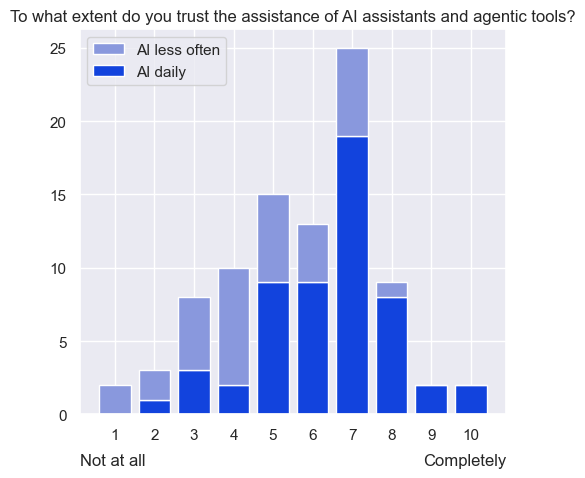

In [32]:
q = "To what extent do you trust the assistance of AI assistants and agentic tools?"

ai_daily = df['ai_freq'].isin(['Daily', 'Continuously'])

_ = plot_one(df, q, (1, 10, 1), 'ai_trust',
             (ai_daily, ['AI daily', 'AI less often']),
             ("Not at all", "Completely"),
             ['#1243dd', '#8998dd']
            )

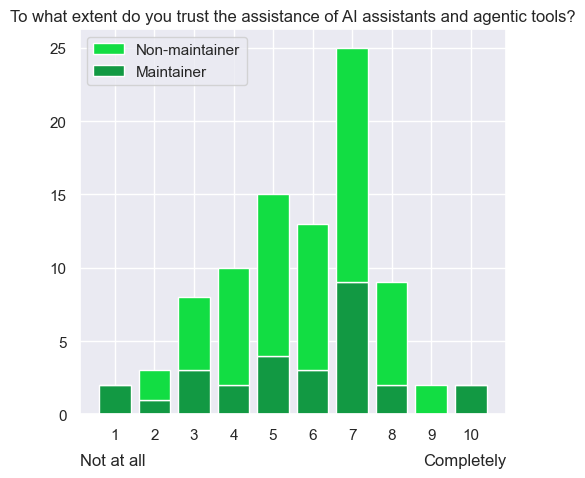

In [33]:
q = "To what extent do you trust the assistance of AI assistants and agentic tools?"

maintainer = df['core'] != 'No'

_ = plot_one(df, q, (1, 10, 1), 'ai_trust',
             (maintainer, ['Maintainer', 'Non-maintainer']),
             ("Not at all", "Completely"),
             ['#129943', '#12dd43']
            )

In [34]:
q = "In the past 6 months, have you used AI code assistants to write, debug, or document code meant for subsurface open-source applications?"

counts = (df['ai_subsurface']
      .value_counts(sort=False)
      .reset_index()
)
(counts.style
       .hide(axis='index')
       .set_caption(q)
)

ai_subsurface,count
"No, I don't code",9
"No, I code but I don't use AI for programming tasks",5
"Yes, occasionally",37
"Yes, frequently",38


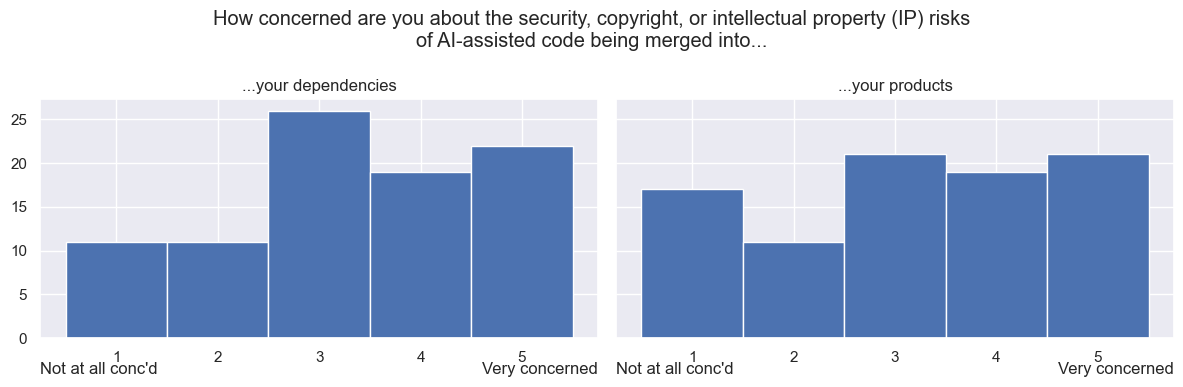

In [35]:
q0 = "...your dependencies"
q1 = "...your products"

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(12, 4), sharey=True)
_ = ax0.hist(df['ip_depend'], bins=np.arange(0.5, 6.5), align='mid')
_ = ax1.hist(df['ip_merge'], bins=np.arange(0.5, 6.5), align='mid')
ax0.set_title(q0)
ax1.set_title(q1)
for s, x, ha in [("Not at all conc'd", 0, 'left'), ("Very concerned", 1, 'right')]:
    ax0.annotate(s, xy=(x, -0.1), xycoords='axes fraction', ha=ha, va='top')
    ax1.annotate(s, xy=(x, -0.1), xycoords='axes fraction', ha=ha, va='top')
plt.suptitle("How concerned are you about the security, copyright, or intellectual property (IP) risks\nof AI-assisted code being merged into...")
plt.tight_layout()

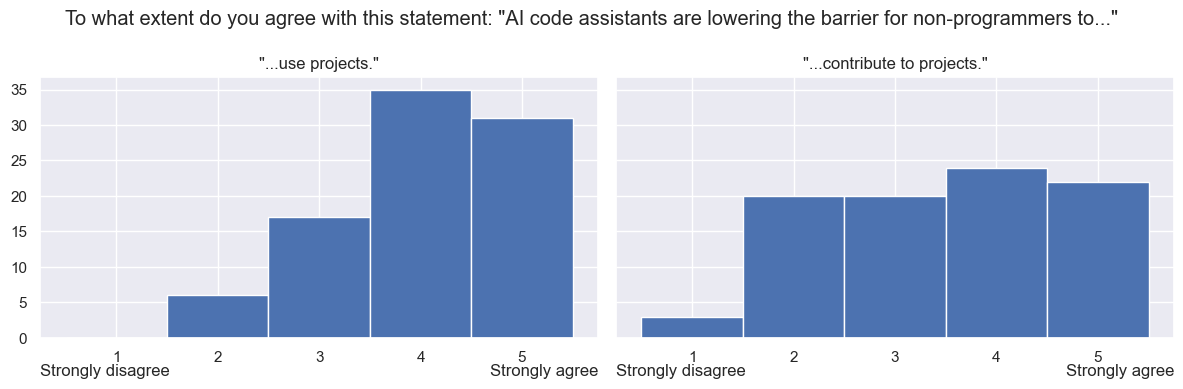

In [36]:
q0 = '"...use projects."' 
q1 = '"...contribute to projects."' 

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(12, 4), sharey=True)
_ = ax0.hist(df['barrier_use'], bins=np.arange(0.5, 6.5), align='mid')
_ = ax1.hist(df['barrier_contrib'], bins=np.arange(0.5, 6.5), align='mid')
ax0.set_title(q0)
ax1.set_title(q1)
for s, x, ha in [("Strongly disagree", 0, 'left'), ("Strongly agree", 1, 'right')]:
    ax0.annotate(s, xy=(x, -0.1), xycoords='axes fraction', ha=ha, va='top')
    ax1.annotate(s, xy=(x, -0.1), xycoords='axes fraction', ha=ha, va='top')
plt.suptitle('To what extent do you agree with this statement: "AI code assistants are lowering the barrier for non-programmers to..."')
plt.tight_layout()

---
## Funding and sustainability

<div class="alert alert-block alert-info" style="padding-bottom:24px;">
  <ul>
    <li>In the past 6 months, how would you characterize your organizational leadership’s general attitude toward adopting open-source software? <code>df['leaders']</code></li>
    <li>Which of the following actions has your organization taken? Select all that apply. <code>df['org_actions']</code></li>
    <li>In the last 6 months, and to the best of your knowledge, have any of your projects been affected by an upstream dependency doing any of the following:
        <ul>
            <li>Changing its license <code>df['dep_license']</code></li>
            <li>Being forked <code>df['dep_fork']</code></li>
            <li>Being deprecated <code>df['dep_deprecated']</code></li>
            <li>Being attacked or infected <code>df['dep_attack']</code></li>
        </ul></li>
    <li>Based on your observations in the past 6 months, how sustainable do you consider the maintenance health of the subsurface open-source ecosystem? <code>df['sustainable']</code></li>
  </ul>
</div>

In [37]:
q = "In the past 6 months, how would you characterize your organizational leadership’s general attitude toward adopting open-source software?"

counts = (df['leaders']
      .value_counts(sort=False)
      .reset_index()
)

(counts.style
       .set_properties(**{'width': '140px'})
       .hide(axis='index')
       .set_caption(q)
)

leaders,count
Hostile,2
Skeptical,14
Indifferent,19
Curious,1
Supportive,30
Enthusiastic,23


In [38]:
q = "Which of the following actions has your organization taken? Select all that apply."

counts = (df['org_actions']
    .explode()
    .value_counts(sort=True, ascending=True)
    .reset_index(name='count')
)
(counts.loc[counts['count'] > 1]
       .style
       .hide(axis='index')
       .set_caption(q)
)
# NB Respondents could choose multiple actions.

org_actions,count
Implemented an Open Source Program Office (OSPO) or similar open source team,6
"Funded open source (via foundation membership, sponsorship of individual developers, donations, etc)",9
Defined a public position on open source,10
Joined or associated with open source organizations,10
Explicitly provided engineering or infrastructure support to open source projects,10
Defined a clear and visible open source strategy,16
Expressed a preference for open source software,27
None of the above,49


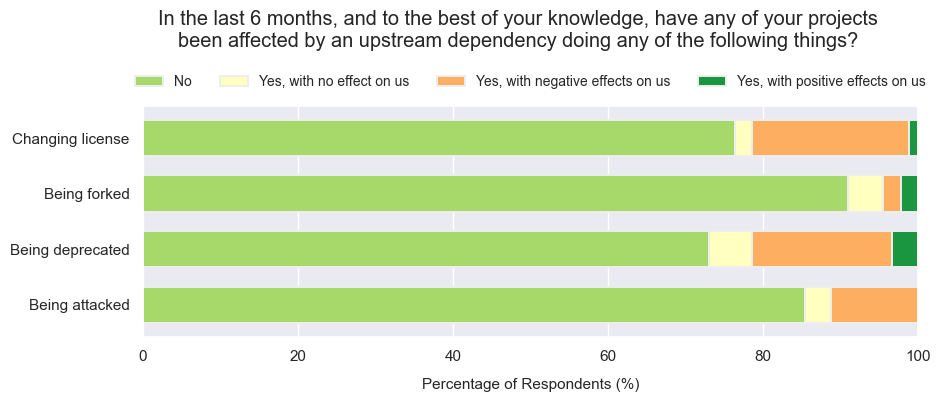

In [39]:
q = "In the last 6 months, and to the best of your knowledge, have any of your projects\nbeen affected by an upstream dependency doing any of the following things?"
columns_dict = {
    'dep_license': 'Changing license',
    'dep_fork': 'Being forked',
    'dep_deprecated': 'Being deprecated',
    'dep_attack': 'Being attacked',
}

cats = df['dep_license'].dtype.categories
plot_data = {}
for col, label in columns_dict.items():
    counts = df[col].value_counts(normalize=True).reindex(cats).fillna(0) * 100
    plot_data[label] = counts
plot_df = pd.DataFrame(plot_data).T

fig, ax = plt.subplots(figsize=(10, 3))
colors = ['#a6d96a', '#ffffbf', '#fdae61', '#1a9641']
plot_df.plot(kind='barh', stacked=True, ax=ax, color=colors, edgecolor='#eeeeee', lw=1.4, width=0.65)
ax.set_xlabel('Percentage of Respondents (%)', fontsize=11, labelpad=10)
ax.set_xlim(0, 100)
ax.invert_yaxis()
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=5, fontsize=10, frameon=False)
plt.suptitle(q, y=1.2)
plt.show()

In [40]:
q = "Based on your observations in the past 6 months, how sustainable do you consider the maintenance health of the subsurface open-source ecosystem?"

counts = (df['sustainable']
      .value_counts(sort=False)
      .reset_index()
)

(counts.style
       .set_properties(**{'width': '150px'})
       .hide(axis='index')
       .set_caption(q)
)

sustainable,count
Critical,3
Fragile,35
Stable,47
Robust,4


---

## Other

<div class="alert alert-block alert-info" style="padding-bottom:24px;">
  <ul>
    <li>That's the end of the survey. Is there anything you'd like to share? <code>df['other']</code></li>
  </ul>
</div>

In [41]:
df['other'].unique()

<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              nan,
                                                                                                                                                                                                      

---

2026 — CC BY — Matt Hall — mtha@equinor.com